# F4 — Black Box Optimisation (Week 06)

**Structure:** Config → Load → Surrogate → Acquisition → Diagnostics → Output

This notebook:
- Retrains an **ExtraTrees ensemble** surrogate on the latest `(X, y)` data.
- Estimates uncertainty via **ensemble disagreement** (std across ensemble members).
- Recomputes acquisition (**LCB + diversity penalty**) and selects **one** next point.

**Assumption:** minimisation (more negative is better).


In [1]:

# =========================
# IMPORTS (GLOBAL)
# =========================
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import ExtraTreesRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, r2_score

from scipy.stats.qmc import Sobol


In [2]:

# =========================
# 0) CONFIG (F4) — Week 06
# =========================
FN = "F4"
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Paths (course repo)
INPUTS_PATH = "data/F4/initial_inputs.npy"
OUTPUTS_PATH = "data/F4/initial_outputs.npy"

# Fallback paths (sandbox / Colab)
FALLBACK_INPUTS = "/mnt/data/initial_inputs.npy"
FALLBACK_OUTPUTS = "/mnt/data/initial_outputs.npy"

# Surrogate
N_ENSEMBLE = 12
N_TREES = 700
MIN_LEAF = 2

# Acquisition
N_CAND = 8192
KAPPA = 1.2
LAMBDA_DIST = 0.05

TOPK_BACKUPS = 8
EPS_SIGMA = 1e-9


In [3]:

# =========================
# 1) LOAD DATA
# =========================
in_path = INPUTS_PATH if os.path.exists(INPUTS_PATH) else FALLBACK_INPUTS
out_path = OUTPUTS_PATH if os.path.exists(OUTPUTS_PATH) else FALLBACK_OUTPUTS

X = np.load(in_path)
y = np.load(out_path).ravel()

assert X.ndim == 2
assert X.shape[0] == y.shape[0]

d = X.shape[1]
BOUNDS = np.array([[0.0, 1.0]] * d)

print(f"Loaded {FN}: X={X.shape}, y={y.shape}")
print(f"y stats: min={y.min():.6f}, max={y.max():.6f}, mean={y.mean():.6f}, std={y.std():.6f}")


Loaded F4: X=(35, 4), y=(35,)
y stats: min=-46.393388, max=0.580272, mean=-16.116787, std=9.935555


In [4]:

# =========================
# 2) SURROGATE + UNCERTAINTY
# =========================
def make_model(seed):
    return ExtraTreesRegressor(
        n_estimators=N_TREES,
        min_samples_leaf=MIN_LEAF,
        max_features="sqrt",
        random_state=seed,
        n_jobs=-1,
        bootstrap=False
    )

models = []
for i in range(N_ENSEMBLE):
    m = make_model(RANDOM_SEED + i)
    m.fit(X, y)
    models.append(m)

pred_train = np.stack([m.predict(X) for m in models], axis=0)
mu_train = pred_train.mean(axis=0)
sigma_train = pred_train.std(axis=0, ddof=1) + EPS_SIGMA

print("Surrogate trained.")


Surrogate trained.


In [5]:

# =========================
# 3) ACQUISITION (LCB + DIVERSITY)
# =========================
sampler = Sobol(d=d, scramble=True, seed=RANDOM_SEED)
m_pow = int(np.ceil(np.log2(N_CAND)))
Xcand = sampler.random_base2(m=m_pow)[:N_CAND]

for j in range(d):
    Xcand[:, j] = np.clip(Xcand[:, j], 0.0, 1.0)

pred_c = np.stack([m.predict(Xcand) for m in models], axis=0)
mu_c = pred_c.mean(axis=0)
sigma_c = pred_c.std(axis=0, ddof=1) + EPS_SIGMA

diff = Xcand[:, None, :] - X[None, :, :]
dist = np.sqrt((diff ** 2).sum(axis=2))
min_dist = dist.min(axis=1)

lcb = mu_c - KAPPA * sigma_c
score = lcb - LAMBDA_DIST * min_dist

best_idx = int(np.argmin(score))
x_next = Xcand[best_idx]

print("x_next:", np.round(x_next, 6))
print(f"μ={mu_c[best_idx]:.6f}, σ={sigma_c[best_idx]:.6f}, min_dist={min_dist[best_idx]:.6f}")


x_next: [0.986623 0.953357 0.992406 0.977525]
μ=-35.187691, σ=0.228661, min_dist=0.136836


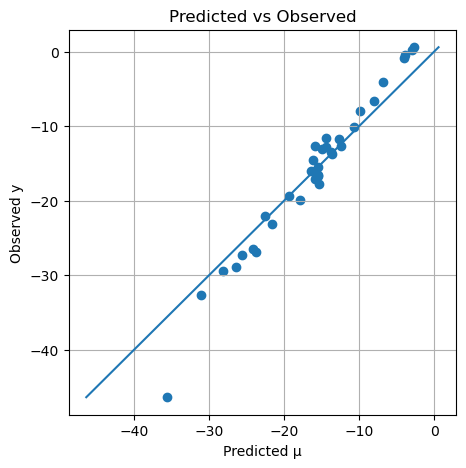

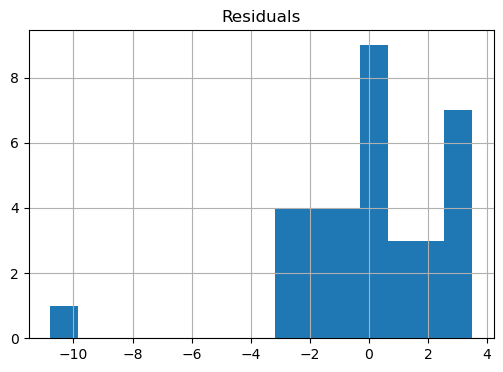

,feature,importance
1,x2,0.304170
0,x1,0.280007
3,x4,0.263649
2,x3,0.152174


In [6]:

# =========================
# 4) DIAGNOSTICS
# =========================
plt.figure(figsize=(5,5))
plt.scatter(mu_train, y)
lo, hi = min(mu_train.min(), y.min()), max(mu_train.max(), y.max())
plt.plot([lo, hi], [lo, hi])
plt.xlabel("Predicted μ")
plt.ylabel("Observed y")
plt.title("Predicted vs Observed")
plt.grid(True)
plt.show()

resid = y - mu_train
plt.figure(figsize=(6,4))
plt.hist(resid, bins=15)
plt.title("Residuals")
plt.grid(True)
plt.show()

importances = np.mean([m.feature_importances_ for m in models], axis=0)
imp_df = pd.DataFrame(
    {"feature": [f"x{i+1}" for i in range(d)], "importance": importances}
).sort_values("importance", ascending=False)

display(imp_df)


In [7]:

# =========================
# 5) OUTPUT (SUBMIT ONE ROW)
# =========================
print("=== SUBMIT THIS ===")
print("x_next =", np.round(x_next, 6))

rank = np.argsort(score)[:TOPK_BACKUPS]
print("\nBackups:")
for i, idx in enumerate(rank):
    print(f"{i+1:02d}: {np.round(Xcand[idx], 6)}")


=== SUBMIT THIS ===
x_next = [0.986623 0.953357 0.992406 0.977525]

Backups:
01: [0.986623 0.953357 0.992406 0.977525]
02: [0.993153 0.969553 0.907325 0.849562]
03: [0.943764 0.896856 0.879852 0.883614]
04: [0.969722 0.840648 0.781119 0.993158]
05: [0.950051 0.912658 0.966642 0.755728]
06: [0.89049  0.999884 0.865429 0.914665]
07: [0.966748 0.942739 0.900496 0.632828]
08: [0.933577 0.931385 0.760733 0.945999]
